In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [ ]:
from ml.preprocess import (
    load_detect_dataset,
    load_class_dataset,
    scale_data,
    create_sequences,
    get_dataset_stats,
    SENSOR_COLS,
)
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
from ml.isolation_forest import train_isolation_forest, get_anomaly_scores, save_model as save_if
from ml.lstm_model import train_lstm, get_reconstruction_errors, set_threshold, load_model
from ml.hybrid import hybrid_predict, classify_severity
from ml.explainability import (
    explain_with_shap,
    plot_shap_summary,
    explain_single_anomaly,
    get_top_contributing_sensors,
)

In [4]:
# Preprocessing detect_dataset

X, y = load_detect_dataset("../data/raw/detect_dataset.csv")
get_dataset_stats(X, y)

feature_names = SENSOR_COLS   # ["Ia", "Ib", "Ic", "Va", "Vb", "Vc"]
X_scaled, scaler = scale_data(X)
X_seq, y_seq = create_sequences(X_scaled, y, timesteps=10)


   detect_dataset loaded: 12001 rows
   Normal: 6505 | Fault: 5496
   Fault rate: 45.8%

 Dataset Statistics:
              Ia         Ib         Ic         Va         Vb         Vc
count  12001.000  12001.000  12001.000  12001.000  12001.000  12001.000
mean       6.709    -26.558     22.353      0.011     -0.015      0.005
std      377.158    357.459    302.053      0.346      0.358      0.349
min     -883.542   -900.527   -883.358     -0.621     -0.660     -0.613
25%      -64.349    -51.422    -54.562     -0.238     -0.314     -0.279
50%       -3.240      4.711     -0.399      0.002     -0.007      0.008
75%       53.823     69.638     45.275      0.285      0.249      0.290
max      885.739    889.869    901.274      0.610      0.628      0.608

Class balance — Normal: 6505 | Fault: 5496


In [5]:
TIMESTEPS = 10
X_seq, y_seq = create_sequences(X_scaled, y, timesteps=TIMESTEPS)


In [6]:
if_model = train_isolation_forest(X_scaled)
if_scores, if_labels = get_anomaly_scores(if_model, X_scaled)
save_if(if_model, path="../models/isolation_forest.pkl")

  Isolation Forest saved → ../models/isolation_forest.pkl


In [7]:
normal_mask = y_seq == 0
X_normal_seq = X_seq[normal_mask]
lstm_model, train_losses = train_lstm(X_normal_seq, epochs=40)

Training on: cpu
Epoch   0 | Train Loss: 0.23019 | Val Loss: 0.16640
Epoch   5 | Train Loss: 0.02125 | Val Loss: 0.01817
Epoch  10 | Train Loss: 0.01318 | Val Loss: 0.00784
Epoch  15 | Train Loss: 0.01112 | Val Loss: 0.00871
Epoch  20 | Train Loss: 0.00992 | Val Loss: 0.00954
Epoch  25 | Train Loss: 0.00946 | Val Loss: 0.00664
Epoch  30 | Train Loss: 0.00838 | Val Loss: 0.00673
Epoch  35 | Train Loss: 0.00784 | Val Loss: 0.00556


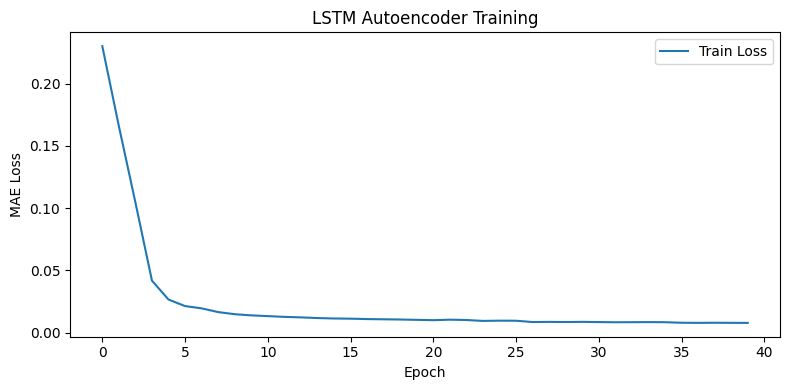

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch"); plt.ylabel("MAE Loss")
plt.title("LSTM Autoencoder Training")
plt.legend(); plt.tight_layout()
plt.savefig("../models/training_curve.png", dpi=150)


In [ ]:
lstm_errors = get_reconstruction_errors(lstm_model, X_seq)
threshold = set_threshold(lstm_errors[normal_mask])

In [ ]:
if_labels_seq = if_labels[TIMESTEPS:]
combined_labels, confidence_scores = hybrid_predict(if_labels_seq, lstm_errors, threshold)


In [ ]:
print("\n📋 Classification Report:")
print(classification_report(y_seq, combined_labels, target_names=["Normal", "Fault"]))

try:
    auc = roc_auc_score(y_seq, confidence_scores)
    print(f"📈 ROC-AUC Score: {auc:.4f}")
except Exception as e:
    print(f"AUC error: {e}")


In [ ]:
print("\n🔍 Running SHAP explanations...")
shap_values = explain_with_shap(if_model, X_scaled, feature_names)
plot_shap_summary(shap_values, X_scaled, feature_names)

# Explain the first detected anomaly
anomaly_indices = np.where(combined_labels == 1)[0]
if len(anomaly_indices) > 0:
    sample = anomaly_indices[0]
    explain_single_anomaly(shap_values, X_scaled, sample, feature_names)
    reasons = get_top_contributing_sensors(shap_values, sample, feature_names)

    print(f"\n🚨 Anomaly #{sample} — Severity: {classify_severity(confidence_scores[sample])}")
    print("Root cause sensors:")
    for r in reasons:
        print(f"  → {r['sensor']}: {r['direction']} (impact: {r['impact']})")
